<a href="https://colab.research.google.com/github/harshwardhanjhala/Amazon-reviews-analysis/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/Reviews.csv")
df.shape

(568454, 10)

In [5]:
df=df.sample(n=30000,random_state=42) # randomly selecting 30000 rows for fast processing
df.shape
df.to_csv("Reviews_small.csv",index=False)

In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 165256 to 282784
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      30000 non-null  int64 
 1   ProductId               30000 non-null  object
 2   UserId                  30000 non-null  object
 3   ProfileName             30000 non-null  object
 4   HelpfulnessNumerator    30000 non-null  int64 
 5   HelpfulnessDenominator  30000 non-null  int64 
 6   Score                   30000 non-null  int64 
 7   Time                    30000 non-null  int64 
 8   Summary                 29999 non-null  object
 9   Text                    30000 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.5+ MB


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04
mean,284665.357367,1.766033,2.244633,4.184767,1.295672e+09
std,164742.917574,7.459304,8.095763,1.307702,4.841529e+07
min,3.000000,0.000000,0.000000,1.000000,9.482400e+08
25%,141943.000000,0.000000,0.000000,4.000000,1.269821e+09
50%,283102.500000,0.000000,1.000000,5.000000,1.310688e+09
75%,427436.750000,2.000000,2.000000,5.000000,1.332461e+09
max,568425.000000,454.000000,462.000000,5.000000,1.351210e+09


In [7]:
df=df.dropna(subset=["Text","Score"])
df=df.drop_duplicates()
df['Time']=pd.to_datetime(df['Time'],unit='s')
df = df[['ProductId', 'UserId', 'Score', 'Time', 'Summary', 'Text']]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 165256 to 282784
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ProductId  30000 non-null  object        
 1   UserId     30000 non-null  object        
 2   Score      30000 non-null  int64         
 3   Time       30000 non-null  datetime64[ns]
 4   Summary    29999 non-null  object        
 5   Text       30000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 1.6+ MB


In [8]:
# numeric_df = df.select_dtypes(include='number')
# numeric_df.corr()

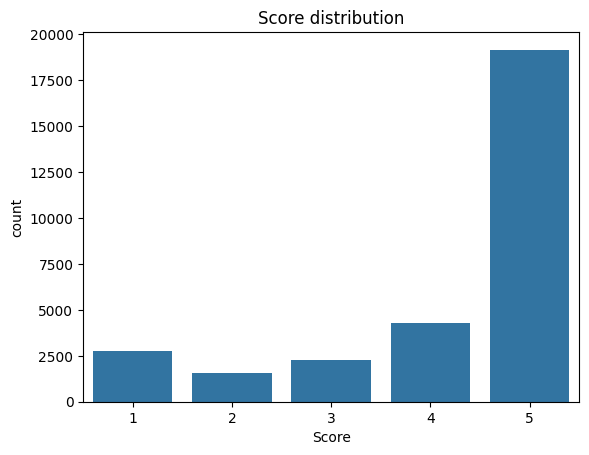

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df,x='Score')
plt.title("Score distribution")
plt.show()

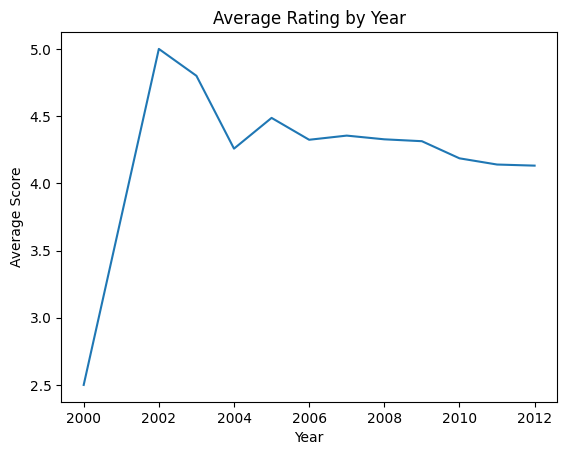

In [10]:
df.groupby(df['Time'].dt.year)['Score'].mean().plot(kind='line')
plt.title("Average Rating by Year")
plt.ylabel("Average Score")
plt.xlabel("Year")
plt.show()

In [11]:
from textblob import TextBlob
def get_sentiment(text):                                   # function for calculating sentiment polarity from text review
    return TextBlob(str(text)).sentiment.polarity
df['sentiment'] = df['Text'].apply(get_sentiment)

# Quick check
df[['Text', 'sentiment']].head()

,Text,sentiment
165256,Having tried a couple of other brands of glute...,0.319318
231465,My cat loves these treats. If ever I can't fin...,0.435370
427827,A little less than I expected. It tends to ha...,-0.010833
433954,"First there was Frosted Mini-Wheats, in origin...",0.159401
70260,and I want to congratulate the graphic artist ...,0.235565


In [12]:
def label_sentiment(polarity):           # assigning label to polarity
    if polarity > 0:
        return 'Positive'
    elif polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment_Label'] = df['sentiment'].apply(label_sentiment)

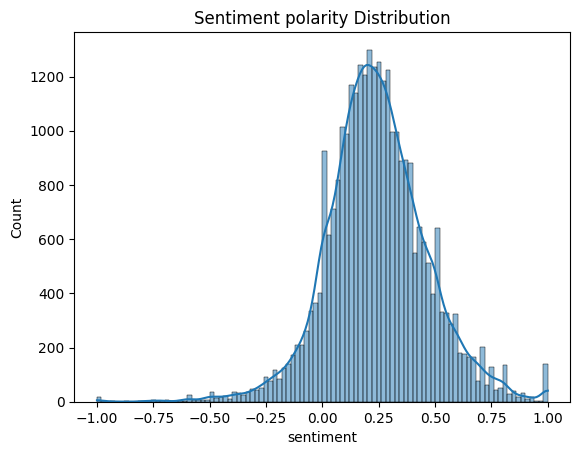

In [13]:
sns.histplot(df['sentiment'],bins=100,kde=True)
plt.title("Sentiment polarity Distribution")
plt.show()

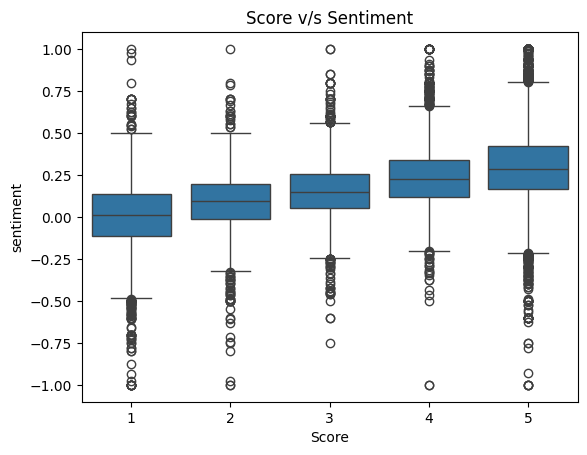

In [14]:
sns.boxplot(x='Score',y='sentiment',data=df)
plt.title("Score v/s Sentiment")
plt.show()

In [15]:
df.head()

,ProductId,UserId,Score,Time,Summary,Text,sentiment,Sentiment_Label
165256,B000EVG8J2,A1L01D2BD3RKVO,5,2010-03-10,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...,0.319318,Positive
231465,B0000BXJIS,A3U62RE5XZDP0G,5,2011-03-01,great kitty treats,My cat loves these treats. If ever I can't fin...,0.435370,Positive
427827,B008FHUFAU,AOXC0JQQZGGB6,3,2008-10-15,COFFEE TASTE,A little less than I expected. It tends to ha...,-0.010833,Negative
433954,B006BXV14E,A3PWPNZVMNX3PA,2,2012-04-25,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin...",0.159401,Positive
70260,B007I7Z3Z0,A1XNZ7PCE45KK7,5,2012-04-18,Great Taste . . .,and I want to congratulate the graphic artist ...,0.235565,Positive


In [16]:
df.to_csv("amazon_cleaned.csv", index=False)
